# Fourier Transform

AI: The Fourier Transform is a mathematical tool used to convert a signal from the time (or spatial) domain into the frequency domain. It shows what frequencies are present in a signal and how strong they are.

**Key Ideas**

* Any complex signal can be expressed as a sum of simple sine and cosine waves.
* The Fourier Transform tells you which frequencies exist and their amplitudes.
* It is fundamental for analyzing signals that change over time or space.

**Why It’s Useful**

* Reveals hidden frequency information
* Simplifies analysis of signals and systems
* Helps filter noise, compress data, and analyze patterns

**Common Types**

* Fourier Series – For periodic signals
* Fourier Transform (FT) – For continuous, non‑periodic signals
* Discrete Fourier Transform (DFT) – For discrete data
* Fast Fourier Transform (FFT) – Efficient algorithm to compute the DFT

**Applications**

* Signal processing (audio, image, video)
* Communications and wireless systems
* Medical imaging (MRI, CT scans)
* Physics and engineering
* Data analysis and pattern recognition



In [1]:
import numpy as np
import matplotlib.pyplot as plt
# to integrate
from scipy import interpolate
import scipy.integrate as integrate

import pandas as pd

## Example 1: Intro
The following example provides a visual illustration of how the Fourier transform's integral measures whether a frequency is present in a particular function. 

Let's consider the next example to introduce the Fourier transformate. Let's $$f(t)=100\,e^{-\pi\,t^2}\,\cos(2\pi\,3t)$$ with $\omega_0=2\pi\,3$ Hz and frecuency $f=2\pi/\omega\approx 0.33$ Hz. Also consider $g(t,\omega)=\dfrac{1}{\sqrt{2\pi}}\,e^{-i\,2\pi\omega t}$ the continuos Fourier basis.

In [7]:
def f(t):
    return 100*np.exp(-np.pi*t**2)*np.cos(2*np.pi*3*t)

def g(t,w):
    return 1./(2*np.pi)*np.exp(-1j*2*np.pi*w*t)

Let's plot $f(t)\times g(t,w)$ for two frecuencies $\omega=\{3,5,...\}$ Hz and compute the integrals for the Re and Img in $x\,\epsilon\,[a,b]$. Notice that $\omega=3$ Hz is just the frecuency (actually $\omega_0=2\pi\omega$).

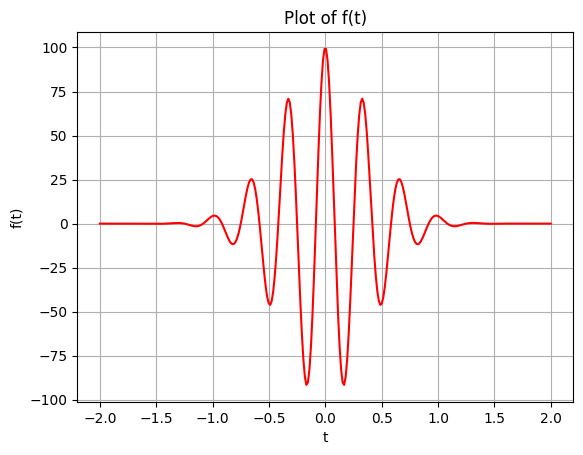

Integral of f(t) = -1.7449644601374992e-05


In [8]:
t = np.linspace(-2,2,300)

plt.plot(t, f(t),'r-')
plt.grid()
plt.title('Plot of f(t)')
plt.xlabel('t')
plt.ylabel('f(t)')
plt.show()

A = integrate.quad(lambda t: f(t), t.min(), t.max())[0]
print('Integral of f(t) =', A)

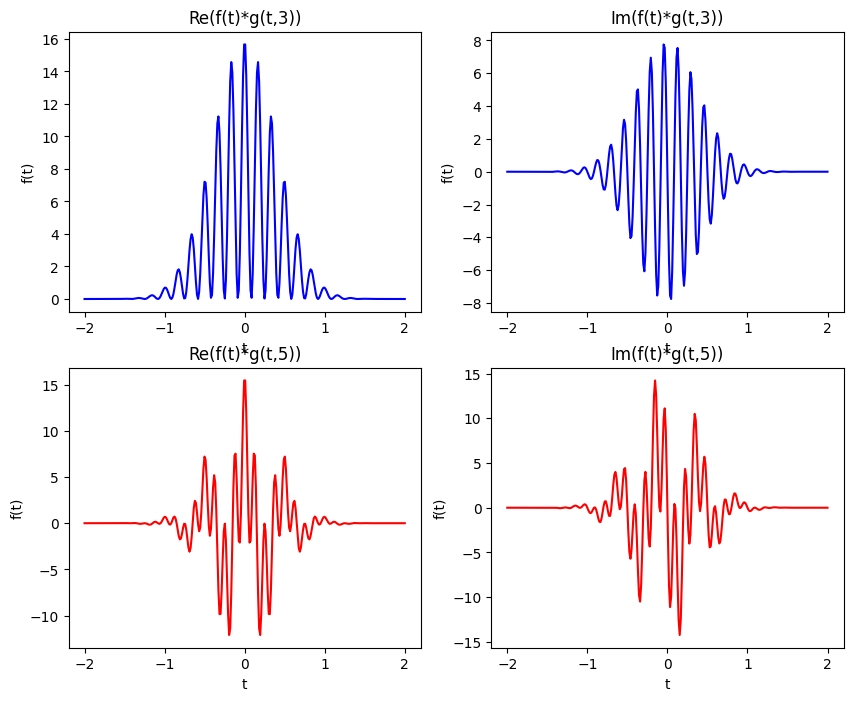

In [9]:
plt.figure(figsize=(10,8))
plt.subplot(2,2,1)
plt.plot(t, f(t)*g(t,3).real,'b-')
plt.title('Re(f(t)*g(t,3))')
plt.xlabel('t')
plt.ylabel('f(t)')

plt.subplot(2,2,2)
plt.plot(t, f(t)*g(t,3).imag,'b-')
plt.title('Im(f(t)*g(t,3))')
plt.xlabel('t')
plt.ylabel('f(t)')

plt.subplot(2,2,3)
plt.plot(t, f(t)*g(t,5).real,'r-')
plt.title('Re(f(t)*g(t,5))')
plt.xlabel('t')
plt.ylabel('f(t)')

plt.subplot(2,2,4)
plt.plot(t, f(t)*g(t,5).imag,'r-')
plt.title('Im(f(t)*g(t,5))')
plt.xlabel('t')
plt.ylabel('f(t)')
plt.show()
plt.show()

In [10]:
ARew3 = integrate.quad(lambda t: f(t)*g(t,3).real, t.min(), t.max())[0]
AImw3 = integrate.quad(lambda t: f(t)*g(t,3).imag, t.min(), t.max())[0]
ARew5 = integrate.quad(lambda t: f(t)*g(t,5).real, t.min(), t.max())[0]
AImw5 = integrate.quad(lambda t: f(t)*g(t,5).imag, t.min(), t.max())[0]

print('Integral of Re(f(t)*g(t,3) =', ARew3)
print('Integral of Im(f(t)*g(t,3) =', AImw3)
print('Integral of Re(f(t)*g(t,5) =', ARew5)
print('Integral of Im(f(t)*g(t,5) =', AImw5)

Integral of Re(f(t)*g(t,3) = 7.95774244957613
Integral of Im(f(t)*g(t,3) = 0.0
Integral of Re(f(t)*g(t,5) = 2.52404027455323e-05
Integral of Im(f(t)*g(t,5) = 0.0


Notice that only the integral of the real part and with frecuency $\omega$ near the frecuecny of the $f(t)$ gives us an apreciable value. In this sense this procedure in a selector of frecuecnies.
The general situation is usually more complicated than this, but heuristically this is how **the Fourier transform measures how much of an individual frequency is present in a function ⁠$f(t)$**. 

In general, let's compute the integral for all (some) frecuencies and plot the result.

Fourier transform

\begin{equation}
\boxed{
F(\omega) = \dfrac{1}{\sqrt{2\pi}}\int_\infty f(t)e^{-2\,i\pi\omega} dt}
\end{equation}

In [11]:
# FRECUENCIES spectrum
w = np.linspace(-10,10,100)
df = []
for i in range(len(w)):
    ARew = integrate.quad(lambda t: f(t)*g(t,w[i]).real, t.min(), t.max())[0]
    AImw = integrate.quad(lambda t: f(t)*g(t,w[i]).imag, t.min(), t.max())[0]
    df.append([w[i], ARew, AImw])

# DataFrame
df = pd.DataFrame(df, columns=['w', 'ReTw', 'ImTw'])
df[:3]

,w,ReTw,ImTw
0,-10.00000,-4.384710e-07,0.0
1,-9.79798,-6.827559e-07,0.0
2,-9.59596,1.615035e-06,0.0


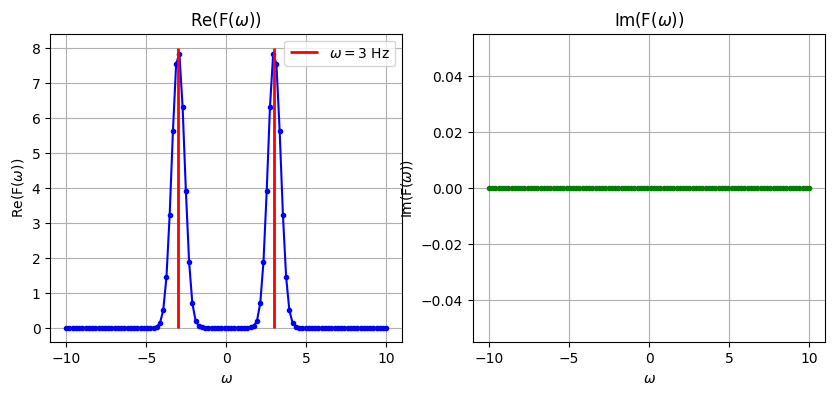

In [22]:
plt.figure(figsize=(10,4))
######## REAL ###########
plt.subplot(1,2,1)
plt.plot(df.w, df.ReTw,'b.')
plt.plot(df.w, df.ReTw,'b-')
plt.vlines(3,0, 8, color='r', lw=2, label='$\\omega=3$ Hz')
plt.vlines(-3,0,8, color='r', lw=2)
plt.title('Re(F($\\omega$))')
plt.xlabel('$\\omega$')
plt.legend(loc='best')
plt.grid()
plt.ylabel('Re(F($\\omega$))')
######### IMAG ##########
plt.subplot(1,2,2)
plt.plot(df.w, df.ImTw,'g.')
plt.title('Im(F($\\omega$))')
plt.xlabel('$\\omega$')
plt.ylabel('Im(F($\\omega$))')
plt.grid()
plt.show()

In this example we realize that the Fourier transform selec the frecuency $\omega = 3$ Hz over a wide range of frecuencies.

## Example 2: 

Let's consider two periodic functions with known frecuencies. Add the funtions and construc (guess) an algorith that recover thoose frecuencies from the combine signal.  

In [110]:
fs = 300 # Sampling frequency (Hz)
t = np.linspace(-3*np.pi, 3*np.pi, fs)

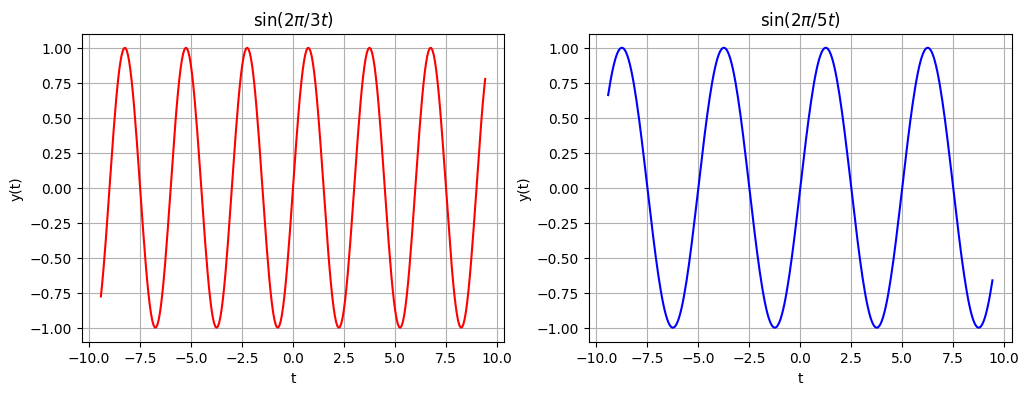

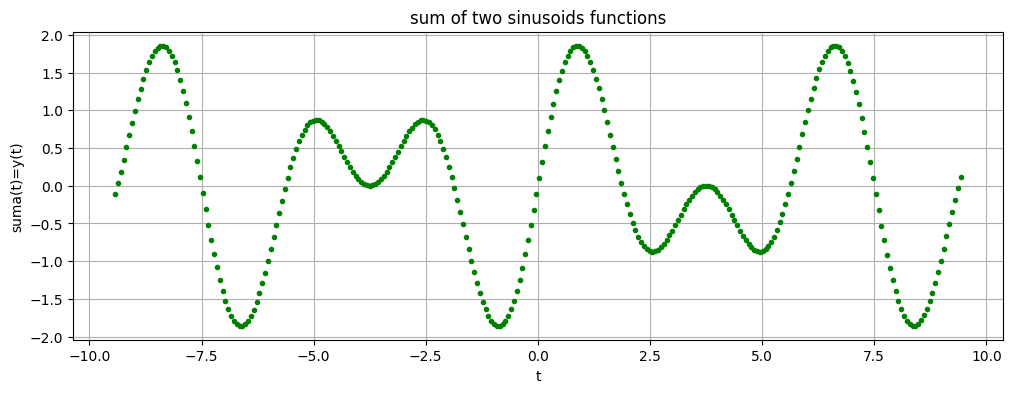

In [111]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(t, np.sin(2*np.pi/3*t),'r-')
plt.title(r'$\sin(2\pi/3t)$')
plt.grid()
plt.xlabel('t')
plt.ylabel('y(t)')
plt.subplot(1,2,2)
plt.plot(t, np.sin(2*np.pi/5*t),'b-')
plt.title(r'$\sin(2\pi/5t)$')
plt.grid()
plt.xlabel('t')
plt.ylabel('y(t)')
plt.show()

###### joint functions ##########
y = np.sin(2*np.pi/3*t)+np.sin(2*np.pi/5*t)
###################
plt.figure(figsize=(12,4))
plt.plot(t, y,'g.')
plt.title('sum of two sinusoids functions')
plt.xlabel('t')
plt.ylabel('suma(t)=y(t)')
plt.grid()
plt.show()

First we need to interpolate the data in green.

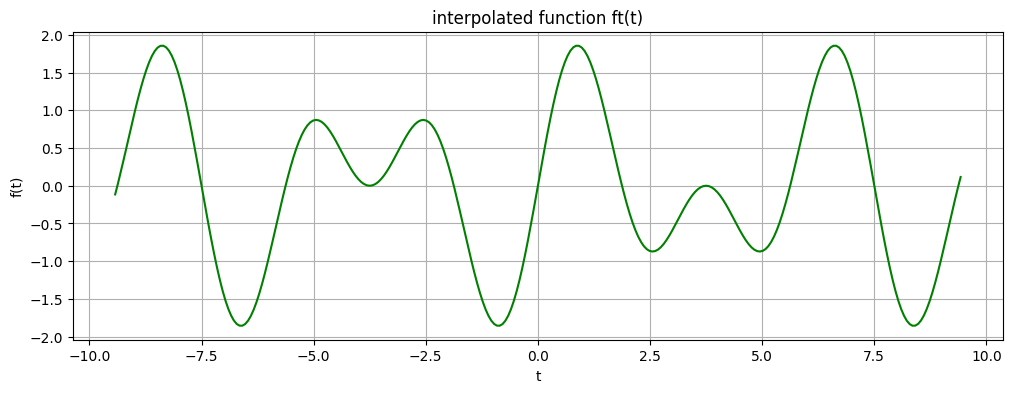

In [112]:
#### DATA in Green (t,y) ######

#Interpolate f(t) to integrate
from scipy import interpolate

f_interp = interpolate.interp1d(t, y, kind='cubic', fill_value='extrapolate')
ft = lambda t: f_interp(t) #Warning

# Plot the interpolated unknown function
plt.figure(figsize=(12,4))
plt.plot(t, ft(t),'g-')
plt.title('interpolated function ft(t)')
plt.xlabel('t')
plt.ylabel('f(t)')
plt.grid()
plt.show()

In [113]:
# Fourier Transform basis
def g(t,w):
    return 1./(2*np.pi)*np.exp(-1j*2*np.pi*w*t)

from scipy import interpolate

def FT(x,y):
    '''Integrate the Fourier Transform of f(t) at frequency w'''

    #Interpolate f(t) to integrate
    f_interp = interpolate.interp1d(x, y, kind='cubic', fill_value='extrapolate')
    ft = lambda t: f_interp(t)

    # range of t to integrate
    t = np.linspace(x.min(), x.max(), 400)

    # FRECUENCIES spectrum to looking for peaks
    w = np.linspace(0,1,100) 

    df = []
    for i in range(len(w)):
        ARew = integrate.quad(lambda t: ft(t)*g(t,w[i]).real, t.min(), t.max())[0]
        AImw = integrate.quad(lambda t: ft(t)*g(t,w[i]).imag, t.min(), t.max())[0]
        df.append([w[i], ARew, AImw])

    # DataFrame
    df = pd.DataFrame(df, columns=['w', 'ReTw', 'ImTw'])
    return df

In [114]:
df = pd.DataFrame(FT(t, y), columns=['w', 'ReTw', 'ImTw'])
df[:3]

/tmp/ipykernel_7564/2164237075.py:23: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  AImw = integrate.quad(lambda t: ft(t)*g(t,w[i]).imag, t.min(), t.max())[0]


,w,ReTw,ImTw
0,0.000000,-1.476930e-16,0.000000
1,0.010101,-1.229794e-16,0.165236
2,0.020202,-1.468879e-16,0.271641


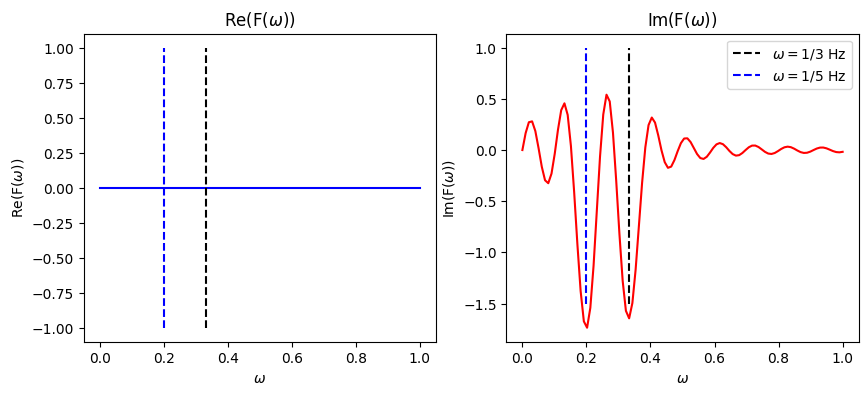

In [115]:
plt.figure(figsize=(10,4))
######## REAL ###########
plt.subplot(1,2,1)
plt.plot(df.w, df.ReTw,'b-')
plt.vlines(1/3, -1, 1, 'k', '--')
plt.vlines(1/5, -1, 1, 'b', '--')
plt.title('Re(F($\\omega$))')
plt.xlabel('$\\omega$')
plt.ylabel('Re(F($\\omega$))')
######### IMAG ##########
plt.subplot(1,2,2)
plt.plot(df.w, df.ImTw,'r-')
plt.vlines(1/3, -1.5, 1, 'k', '--',label='$\\omega=1/3$ Hz')
plt.vlines(1/5, -1.5, 1, 'b', '--',label='$\\omega=1/5$ Hz')
plt.title('Im(F($\\omega$))')
plt.xlabel('$\\omega$')
plt.ylabel('Im(F($\\omega$))')
plt.legend(loc='best')
plt.show()

# Fourier Transform using Numpy and scipy

In Python, the **Fast Fourier Transform** (FFT)—the practical algorithm for the Discrete Fourier Transform (DFT)—is most commonly implemented using the ``SciPy`` and ``NumPy`` libraries. 

Core Libraries

* SciPy (scipy.fft): Generally recommended for scientific applications as it is more feature-rich and often faster than the NumPy equivalent.
* NumPy (numpy.fft): A widely used alternative that is often already installed in many environments.
* OpenCV (cv2.dft): Specifically used for 2D Fourier transforms in image processing

In [116]:
from scipy.fft import fft, fftfreq

# 1. Sample the signal seen before (t,y)
signal = y
#fs = 100 # Sampling frequency (Hz) define in t

# 2. Compute the Fourier Transform
N = len(signal)
yf = fft(signal)
xf = fftfreq(N, 1 / fs)

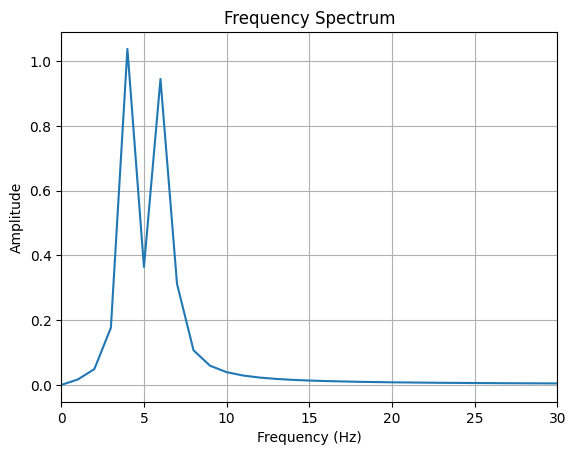

In [117]:
# 3. Plot the magnitude spectrum
plt.plot(xf[:N//2], 2.0/N * np.abs(yf[:N//2])) # Plot positive frequencies only
plt.title('Frequency Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.xlim(0, 30) 
plt.grid()

## Example of a musical signal

Let's consider